In [20]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")

In [21]:
from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
from ML import TwoLens1S
from ML import ThreeLens1S

In [22]:
import numpy as np

# ---------- Roman cadence helpers ----------
def roman_sample(t_days, y, cadence_min=12.1, exp_seconds=67, nsub=7, season_blocks=None):
    """Downsample a dense time series to Roman-like cadence with finite-exposure averaging."""
    t_days = np.asarray(t_days); y = np.asarray(y)
    cad_days = cadence_min / (60.0 * 24.0)
    exp_days = exp_seconds / 86400.0

    # Build sampling grid (respect optional observing seasons)
    if season_blocks is None:
        t0, t1 = t_days.min(), t_days.max()
        start = np.ceil((t0 - t0)/cad_days)*cad_days + t0
        ts = np.arange(start, t1 + 0.5*cad_days, cad_days)
    else:
        chunks = []
        for a, b in season_blocks:
            a = max(a, t_days.min()); b = min(b, t_days.max())
            if a < b: chunks.append(np.arange(a, b + 0.5*cad_days, cad_days))
        if not chunks: return np.array([]), np.array([])
        ts = np.concatenate(chunks)

    # Boxcar average across the exposure using linear interpolation
    offs = np.linspace(-0.5*exp_days, 0.5*exp_days, nsub)
    ys = np.empty_like(ts, dtype=float)
    for i, t0 in enumerate(ts):
        subs = np.clip(t0 + offs, t_days[0], t_days[-1])
        ys[i] = np.interp(subs, t_days, y).mean()
    return ts, ys

def roman_gbt_ds_windows(t_start, n_seasons=6, season_len_days=72, gap_days=0):
    """Simple season windows maker (adjust gap_days if you want spacing)."""
    wins, t = [], float(t_start)
    for _ in range(n_seasons):
        wins.append((t, t + season_len_days))
        t += season_len_days + max(0, gap_days)
    return wins

# ---------- Your parameters ----------
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2   # (not used below, but fine to keep for cross-checks)
u0_list = [-0.0445]

t0 = 0.0
tE = 20.0
rho = 0.0000018
rs = rho

secnum = 45
basenum = 2
num_points = 1000

# ---------- Build your model ----------
triple_model = ThreeLens1S(
    t0, tE, rho, u0_list,
    q2, q3, s2, s3, 357,  # alpha_deg = 357
    psi, rs, secnum, basenum, num_points
)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]

# ---------- Make a dense time grid ----------
# Prefer the class’s own dense grid if it exists; otherwise make ~30s sampling over ±2 tE:
if hasattr(triple_model, "highres_t"):
    t_dense = np.asarray(triple_model.highres_t, dtype=float)
else:
    dt_days = 30.0 / 86400.0
    t_dense = np.arange(t0 - 2*tE, t0 + 2*tE + dt_days, dt_days)

# Run VBM to set geometry & get photometry (even if you only need centroids)
mag, *_ = triple_model.VBM.TripleLightCurve(param, t_dense)

# After you compute centroids:
sys0   = triple_model.systems[0]
cent_x = np.asarray(sys0['cent_x'])
cent_y = np.asarray(sys0['cent_y'])
y1s    = np.asarray(sys0['y1s'])
y2s    = np.asarray(sys0['y2s'])

dx = -(cent_x - y1s)
dy =  (cent_y - y2s)

# Find the matching time array used for these centroids:
# Many implementations stash it as sys0['t'] or triple_model.t
if 't' in sys0:
    t_cent = np.asarray(sys0['t'], dtype=float)
elif hasattr(triple_model, 't'):
    t_cent = np.asarray(triple_model.t, dtype=float)
else:
    # fallback: assume it matches your input t_dense
    t_cent = np.asarray(t_dense, dtype=float)

# Sanity checks (this is what failed before):
assert t_cent.ndim == 1
assert len(t_cent) == len(dx) == len(dy), \
    f"Length mismatch: t={len(t_cent)}, dx={len(dx)}, dy={len(dy)}"

# Optional: drop NaNs/Infs before resampling
mask = np.isfinite(t_cent) & np.isfinite(dx) & np.isfinite(dy)
t_cent = t_cent[mask]; dx = dx[mask]; dy = dy[mask]

# Now sample with the correct time base
ts_dx, dx_s = roman_sample(t_cent, dx, cadence_min=12.1, exp_seconds=67)
_,     dy_s = roman_sample(t_cent, dy, cadence_min=12.1, exp_seconds=67)
dr_s = np.hypot(dx_s, dy_s)

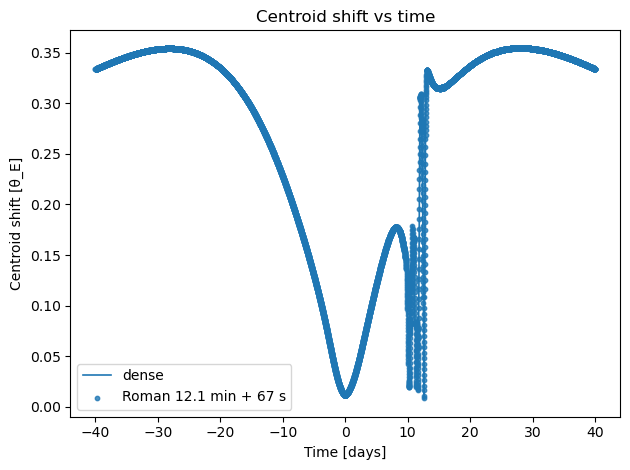

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# If not already:
dr   = np.hypot(dx,  dy)
dr_s = np.hypot(dx_s, dy_s)

plt.figure()
plt.plot(t_cent, dr, lw=1.2, label='dense')
plt.scatter(ts_dx, dr_s, s=10, alpha=0.8, label='Roman 12.1 min + 67 s')
plt.xlabel('Time [days]')
plt.ylabel('Centroid shift [θ_E]')
plt.title('Centroid shift vs time')
plt.legend()
plt.tight_layout()
plt.show()


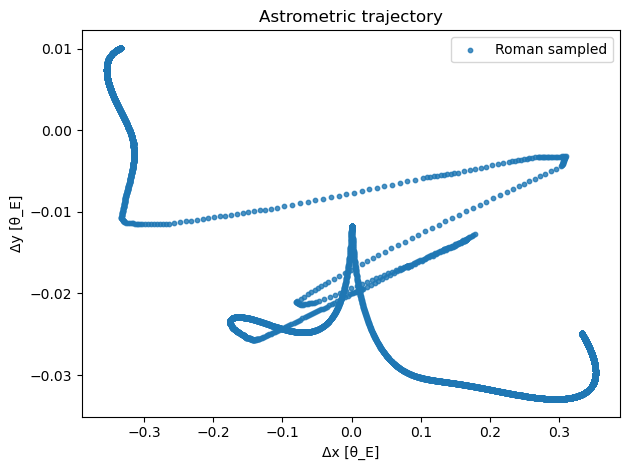

In [24]:
plt.figure()
#plt.plot(dx, dy, lw=1.2, label='dense')
plt.scatter(dx_s, dy_s, s=10, alpha=0.8, label='Roman sampled')
#plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Δx [θ_E]')
plt.ylabel('Δy [θ_E]')
plt.title('Astrometric trajectory')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
three_system = triple_model.systems[0]
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = - delta_x_three
delta_y_three = delta_y_three

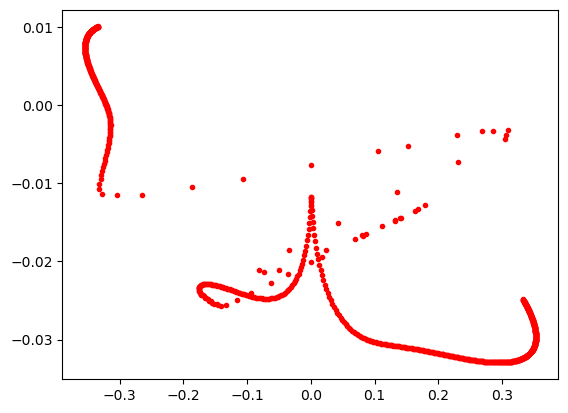

In [26]:
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')

In [27]:
import numpy as np

# ---------- Roman cadence helpers ----------
def roman_sample(t_days, y, cadence_min=12.1, exp_seconds=67, nsub=7, season_blocks=None):
    """Downsample a dense time series to Roman-like cadence with finite-exposure averaging."""
    t_days = np.asarray(t_days); y = np.asarray(y)
    cad_days = cadence_min / (60.0 * 24.0)
    exp_days = exp_seconds / 86400.0

    # Build sampling grid (respect optional observing seasons)
    if season_blocks is None:
        t0, t1 = t_days.min(), t_days.max()
        start = np.ceil((t0 - t0)/cad_days)*cad_days + t0
        ts = np.arange(start, t1 + 0.5*cad_days, cad_days)
    else:
        chunks = []
        for a, b in season_blocks:
            a = max(a, t_days.min()); b = min(b, t_days.max())
            if a < b: chunks.append(np.arange(a, b + 0.5*cad_days, cad_days))
        if not chunks: return np.array([]), np.array([])
        ts = np.concatenate(chunks)

    # Boxcar average across the exposure using linear interpolation
    offs = np.linspace(-0.5*exp_days, 0.5*exp_days, nsub)
    ys = np.empty_like(ts, dtype=float)
    for i, t0 in enumerate(ts):
        subs = np.clip(t0 + offs, t_days[0], t_days[-1])
        ys[i] = np.interp(subs, t_days, y).mean()
    return ts, ys

def roman_gbt_ds_windows(t_start, n_seasons=6, season_len_days=72, gap_days=0):
    """Simple season windows maker (adjust gap_days if you want spacing)."""
    wins, t = [], float(t_start)
    for _ in range(n_seasons):
        wins.append((t, t + season_len_days))
        t += season_len_days + max(0, gap_days)
    return wins

# ---------- Your parameters ----------
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2   # (not used below, but fine to keep for cross-checks)
u0_list = [-0.0445]

t0 = 0.0
tE = 20.0
rho = 0.0000018
rs = rho

secnum = 45
basenum = 2
num_points = 10000

# ---------- Build your model ----------
triple_model = ThreeLens1S(
    t0, tE, rho, u0_list,
    q2, q3, s2, s3, 357,  # alpha_deg = 357
    psi, rs, secnum, basenum, num_points
)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]

# ---------- Make a dense time grid ----------
# Prefer the class’s own dense grid if it exists; otherwise make ~30s sampling over ±2 tE:
if hasattr(triple_model, "highres_t"):
    t_dense = np.asarray(triple_model.highres_t, dtype=float)
else:
    dt_days = 30.0 / 86400.0
    t_dense = np.arange(t0 - 2*tE, t0 + 2*tE + dt_days, dt_days)

# Run VBM to set geometry & get photometry (even if you only need centroids)
mag, *_ = triple_model.VBM.TripleLightCurve(param, t_dense)

# After you compute centroids:
sys0   = triple_model.systems[0]
cent_x = np.asarray(sys0['cent_x'])
cent_y = np.asarray(sys0['cent_y'])
y1s    = np.asarray(sys0['y1s'])
y2s    = np.asarray(sys0['y2s'])

dx = -(cent_x - y1s)
dy =  (cent_y - y2s)

# Find the matching time array used for these centroids:
# Many implementations stash it as sys0['t'] or triple_model.t
if 't' in sys0:
    t_cent = np.asarray(sys0['t'], dtype=float)
elif hasattr(triple_model, 't'):
    t_cent = np.asarray(triple_model.t, dtype=float)
else:
    # fallback: assume it matches your input t_dense
    t_cent = np.asarray(t_dense, dtype=float)

# Sanity checks (this is what failed before):
assert t_cent.ndim == 1
assert len(t_cent) == len(dx) == len(dy), \
    f"Length mismatch: t={len(t_cent)}, dx={len(dx)}, dy={len(dy)}"

# Optional: drop NaNs/Infs before resampling
mask = np.isfinite(t_cent) & np.isfinite(dx) & np.isfinite(dy)
t_cent = t_cent[mask]; dx = dx[mask]; dy = dy[mask]

# Now sample with the correct time base
ts_dx, dx_s = roman_sample(t_cent, dx, cadence_min=12.1, exp_seconds=67)
_,     dy_s = roman_sample(t_cent, dy, cadence_min=12.1, exp_seconds=67)
dr_s = np.hypot(dx_s, dy_s)

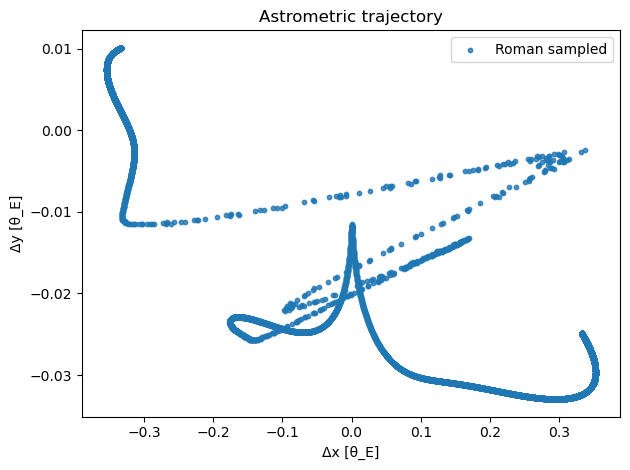

In [28]:
plt.figure()
#plt.plot(dx, dy, lw=1.2, label='dense')
plt.scatter(dx_s, dy_s, s=10, alpha=0.8, label='Roman sampled')
#plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Δx [θ_E]')
plt.ylabel('Δy [θ_E]')
plt.title('Astrometric trajectory')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
three_system = triple_model.systems[0]
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = - delta_x_three
delta_y_three = delta_y_three

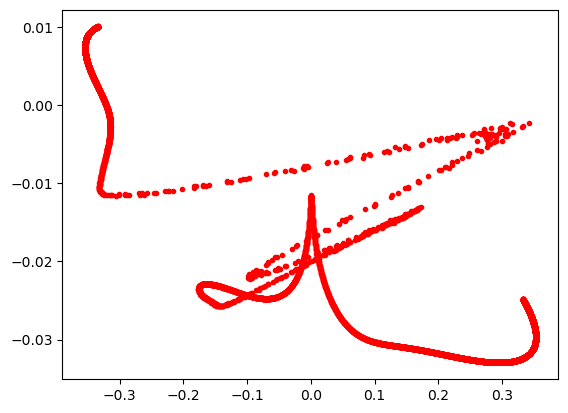

In [30]:
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')

In [31]:
import numpy as np

# ---------- Roman cadence helpers ----------
def roman_sample(t_days, y, cadence_min=12.1, exp_seconds=67, nsub=7, season_blocks=None):
    """Downsample a dense time series to Roman-like cadence with finite-exposure averaging."""
    t_days = np.asarray(t_days); y = np.asarray(y)
    cad_days = cadence_min / (60.0 * 24.0)
    exp_days = exp_seconds / 86400.0

    # Build sampling grid (respect optional observing seasons)
    if season_blocks is None:
        t0, t1 = t_days.min(), t_days.max()
        start = np.ceil((t0 - t0)/cad_days)*cad_days + t0
        ts = np.arange(start, t1 + 0.5*cad_days, cad_days)
    else:
        chunks = []
        for a, b in season_blocks:
            a = max(a, t_days.min()); b = min(b, t_days.max())
            if a < b: chunks.append(np.arange(a, b + 0.5*cad_days, cad_days))
        if not chunks: return np.array([]), np.array([])
        ts = np.concatenate(chunks)

    # Boxcar average across the exposure using linear interpolation
    offs = np.linspace(-0.5*exp_days, 0.5*exp_days, nsub)
    ys = np.empty_like(ts, dtype=float)
    for i, t0 in enumerate(ts):
        subs = np.clip(t0 + offs, t_days[0], t_days[-1])
        ys[i] = np.interp(subs, t_days, y).mean()
    return ts, ys

def roman_gbt_ds_windows(t_start, n_seasons=6, season_len_days=72, gap_days=0):
    """Simple season windows maker (adjust gap_days if you want spacing)."""
    wins, t = [], float(t_start)
    for _ in range(n_seasons):
        wins.append((t, t + season_len_days))
        t += season_len_days + max(0, gap_days)
    return wins

# ---------- Your parameters ----------
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2   # (not used below, but fine to keep for cross-checks)
u0_list = [-0.0445]

t0 = 0.0
tE = 20.0
rho = 0.0000018
rs = rho

secnum = 45
basenum = 2
num_points = 100000

# ---------- Build your model ----------
triple_model = ThreeLens1S(
    t0, tE, rho, u0_list,
    q2, q3, s2, s3, 357,  # alpha_deg = 357
    psi, rs, secnum, basenum, num_points
)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]

# ---------- Make a dense time grid ----------
# Prefer the class’s own dense grid if it exists; otherwise make ~30s sampling over ±2 tE:
if hasattr(triple_model, "highres_t"):
    t_dense = np.asarray(triple_model.highres_t, dtype=float)
else:
    dt_days = 30.0 / 86400.0
    t_dense = np.arange(t0 - 2*tE, t0 + 2*tE + dt_days, dt_days)

# Run VBM to set geometry & get photometry (even if you only need centroids)
mag, *_ = triple_model.VBM.TripleLightCurve(param, t_dense)

# After you compute centroids:
sys0   = triple_model.systems[0]
cent_x = np.asarray(sys0['cent_x'])
cent_y = np.asarray(sys0['cent_y'])
y1s    = np.asarray(sys0['y1s'])
y2s    = np.asarray(sys0['y2s'])

dx = -(cent_x - y1s)
dy =  (cent_y - y2s)

# Find the matching time array used for these centroids:
# Many implementations stash it as sys0['t'] or triple_model.t
if 't' in sys0:
    t_cent = np.asarray(sys0['t'], dtype=float)
elif hasattr(triple_model, 't'):
    t_cent = np.asarray(triple_model.t, dtype=float)
else:
    # fallback: assume it matches your input t_dense
    t_cent = np.asarray(t_dense, dtype=float)

# Sanity checks (this is what failed before):
assert t_cent.ndim == 1
assert len(t_cent) == len(dx) == len(dy), \
    f"Length mismatch: t={len(t_cent)}, dx={len(dx)}, dy={len(dy)}"

# Optional: drop NaNs/Infs before resampling
mask = np.isfinite(t_cent) & np.isfinite(dx) & np.isfinite(dy)
t_cent = t_cent[mask]; dx = dx[mask]; dy = dy[mask]

# Now sample with the correct time base
ts_dx, dx_s = roman_sample(t_cent, dx, cadence_min=12.1, exp_seconds=67)
_,     dy_s = roman_sample(t_cent, dy, cadence_min=12.1, exp_seconds=67)
dr_s = np.hypot(dx_s, dy_s)

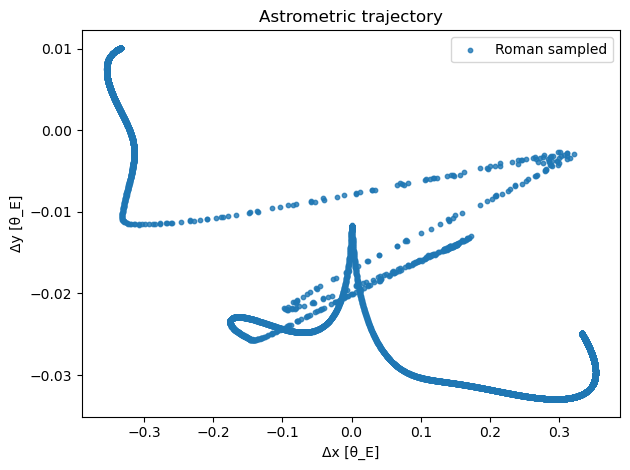

In [32]:
plt.figure()
#plt.plot(dx, dy, lw=1.2, label='dense')
plt.scatter(dx_s, dy_s, s=10, alpha=0.8, label='Roman sampled')
#plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Δx [θ_E]')
plt.ylabel('Δy [θ_E]')
plt.title('Astrometric trajectory')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
three_system = triple_model.systems[0]
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = - delta_x_three
delta_y_three = delta_y_three

(-0.01, -0.002)

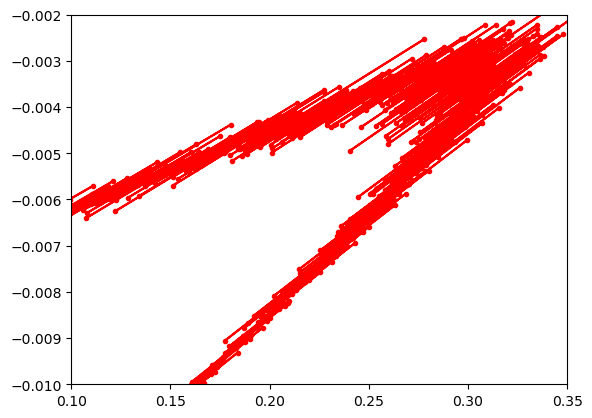

In [39]:
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-', label='Star + Planet + Moon')

plt.xlim(0.1, 0.35)
plt.ylim(-0.01, -.002)

In [35]:
import numpy as np

# stack all columns together
data = np.column_stack([t_dense, mag, dx, dy])
header = "tau,mag,delta_x,delta_y"

np.savetxt("triple_results.txt", data, header=header)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 500000 and the array at index 2 has size 100000

In [36]:
import numpy as np
import pandas as pd

# --- Photometry (native: t_dense) ---
np.savez_compressed("triple_photometry.npz", tau=t_dense, mag=mag)
pd.DataFrame({"tau": t_dense, "mag": mag}).to_csv("triple_photometry.csv", index=False)

# --- Astrometry (native grid) ---
sys0   = triple_model.systems[0]
cent_x = np.asarray(sys0['cent_x'])
cent_y = np.asarray(sys0['cent_y'])
y1s    = np.asarray(sys0['y1s'])
y2s    = np.asarray(sys0['y2s'])

dx = -(cent_x - y1s)
dy =  (cent_y - y2s)

# Try to find the native centroid time grid
candidates = []
for key in ("tau", "t", "time"):
    if isinstance(sys0, dict) and key in sys0:
        candidates.append(np.asarray(sys0[key]))
for attr in ("t", "tau", "highres_t"):
    if hasattr(triple_model, attr):
        candidates.append(np.asarray(getattr(triple_model, attr)))

tau_cent = next((c for c in candidates if c.size == dx.size), None)

# Save NPZ + CSV
if tau_cent is None:
    # Fallback: save with an index if we can't find a matching time grid
    idx = np.arange(dx.size)
    np.savez_compressed("triple_astrometry_native.npz", idx=idx, delta_x=dx, delta_y=dy)
    pd.DataFrame({"idx": idx, "delta_x": dx, "delta_y": dy}).to_csv(
        "triple_astrometry_native.csv", index=False
    )
else:
    np.savez_compressed("triple_astrometry_native.npz", tau_cent=tau_cent, delta_x=dx, delta_y=dy)
    pd.DataFrame({"tau_cent": tau_cent, "delta_x": dx, "delta_y": dy}).to_csv(
        "triple_astrometry_native.csv", index=False
    )
